# Yeast Hog1 osmoregulation — Muzzey et al. (2009) concise dynamic model

Linear three-state model fitted in Muzzey et al., *Cell* 2009, Supplemental Data pp. 9–10
("Concise Dynamic Model Captures Key Data Features"), network scenario (d) of Fig. 4.
H and G are first-order subsystems, I is a scalar gain on the error, D is a pure integrator.

| Symbol | Meaning |
|---|---|
| $u$ | external osmolarity step (NaCl, apparently in M: $u = 0.4$ for 0 → 0.4 M) |
| $s_1$ | H: Hog1 nuclear enrichment |
| $s_2$ | D: integrator driven by Hog1 |
| $s_3$ | G: glycerol-producing subsystem; observed glycerol $= k_g\, s_3$ |
| $e = u - s_3$ | osmotic error |
| $\alpha_i e$ | I: proportional path, bypassing Hog1 |
| $C$ | cell number / biomass (added here, not part of the Muzzey fit) |

$$
\begin{aligned}
\dot s_1 &= k_h\,(u - s_3) - \gamma_h\, s_1 \\
\dot s_2 &= \alpha_d\, s_1 \\
\dot s_3 &= s_2 + \alpha_i\,(u - s_3) - \gamma_g\, s_3 \\
\dot C &= c_1\, C\; \mathbb{1}[s_1 \le \theta_h]
\end{aligned}
$$

All variables are deviations from the pre-stimulus rest state, so $s_1 = s_2 = s_3 = 0$ at $t=0$
($C(0) = 1$).

**Best-fit parameters** (min⁻¹): $k_h = 0.496$, $\gamma_h = 0.369$,
$\gamma_g = 0.119$, $\alpha_i = 0.0806$, $k_g = 7.76$, $\alpha_d = 0.0106$.

**Steady state** (constant $u$): $\dot s_2 = 0 \Rightarrow s_1^* = 0 \Rightarrow s_3^* = u$, $e^* = 0$,
$s_2^* = \gamma_g u$ — perfect adaptation of Hog1, independent of the parameter values.

**Growth.** Hog1 activation arrests the cell cycle (e.g. via Sic1 and Hsl1/Swe1), and growth resumes
once Hog1 adapts. $C$ grows exponentially at $c_1 = \ln 2 / 90\ \mathrm{min}$ while Hog1 is below the
arrest threshold $\theta_h$, and stops otherwise. $C$ is a one-way readout: it does not feed back on
$s_1, s_2, s_3$. Because $s_1$ adapts perfectly, steady-state growth is unaffected by $u$, so only the
transients (and their frequency, under oscillatory input) cost growth. $\theta_h$ is a free parameter
(default 0.05, vs. a peak $s_1 \approx 0.36$); it should be strictly positive, since $s_1 \to 0$ at steady
state and a threshold at 0 would make growth depend on numerical noise.

Note: the glycerol data (Fig. S8C/D) start from a basal level of ~0.4–0.6; the supplement does not say
how that offset was handled, so it is not included here.

Correspondence with the RPA model in this project: $s_1 \leftrightarrow P = k_0(R_0 - \mathrm{Ca})$
(instantaneous, $\gamma_h\to\infty$), $s_2 \leftrightarrow D$ with $\dot D = k_3 P$, $s_3 \leftrightarrow \mathrm{Ca}$,
$u \leftrightarrow R_0$, $\alpha_i e \leftrightarrow k_1 P$. Differences: here the proportional path bypasses
Hog1, and $s_3$ has its own relaxation term $-\gamma_g s_3$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path

PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a matplotlib figure to PLOTS_DIR as a PDF."""
    save_path = PLOTS_DIR / name
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Figure saved to {save_path}")


plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Best-fit parameters, Muzzey et al. 2009 Supplement (units: 1/min)
p = dict(k_h=0.496, gamma_h=0.369, gamma_g=0.119, alpha_i=0.0806, alpha_d=0.0106)
k_g = 7.76   # glycerol output scaling

# Growth readout (not part of the Muzzey fit): growth is arrested while Hog1 is above threshold
p_growth = dict(c1=np.log(2) / 90.0,   # unstressed growth rate, ~90 min doubling
                theta_h=0.05)          # Hog1 arrest threshold (s1 is a deviation; peak ~0.36)


def rhs(t, s, u_fn, k_h, gamma_h, gamma_g, alpha_i, alpha_d, c1, theta_h):
    s1, s2, s3, C = s
    e = u_fn(t) - s3
    return [k_h * e - gamma_h * s1,
            alpha_d * s1,
            s2 + alpha_i * e - gamma_g * s3,
            c1 * C * (s1 <= theta_h)]


def simulate(u_fn, t_span, s0=(0.0, 0.0, 0.0, 1.0), n=4000, **params):
    params = {**p_growth, **params}
    t = np.linspace(*t_span, n)
    sol = solve_ivp(lambda t, s: rhs(t, s, u_fn, **params),
                    t_span, s0, t_eval=t, max_step=0.5, rtol=1e-8, atol=1e-10)
    s1, s2, s3, C = sol.y
    u = np.array([u_fn(tt) for tt in sol.t])
    e = u - s3
    return dict(t=sol.t, u=u, e=e, s1=s1, s2=s2, s3=s3, C=C,
                i=params['alpha_i'] * e, glycerol=k_g * s3)

Figure saved to ../plots/yeast_hog1_step.pdf


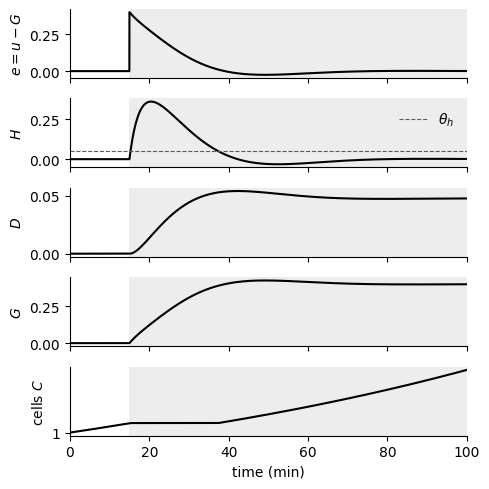

In [ ]:
# Osmotic step 0 -> 0.4 M NaCl at t_step, starting from rest (all deviations = 0)
from matplotlib.ticker import LogLocator, NullLocator, FuncFormatter

u1, t_step = 0.4, 15.0
u_step = lambda t: 0.0 if t < t_step else u1
t_span = (0.0, 100.0)
SHADE_COLOR = '0.93'   # grey == high-osmolarity input on

res = simulate(u_step, t_span, **p)

panels = [('e', '$e = u - G$'),
          ('s1', '$H$'),
          ('s2', '$D$'),
          ('s3', '$G$'),
          ('C', 'cells $C$')]

# input shown as shaded background instead of its own panel
fig, axes = plt.subplots(len(panels), 1, figsize=(5, 5), sharex=True)
for ax, (key, label) in zip(axes, panels):
    ax.axvspan(t_step, t_span[1], color=SHADE_COLOR, lw=0, zorder=0)
    ax.plot(res['t'], res[key], color='k', lw=1.5)
    ax.set_ylabel(label)
axes[1].axhline(p_growth['theta_h'], color='tab:red', ls='--', lw=0.8, label=r'$\theta_h$')
axes[1].legend(frameon=False)
# axes[-1].set_yscale('log')
axes[-1].yaxis.set_major_locator(LogLocator(base=2))
axes[-1].yaxis.set_minor_locator(NullLocator())
axes[-1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}'))
axes[-1].set_xlim(t_span)
axes[-1].set_xlabel('time (min)')
fig.tight_layout()
save_fig(fig, 'yeast_hog1_step.pdf')
plt.show()

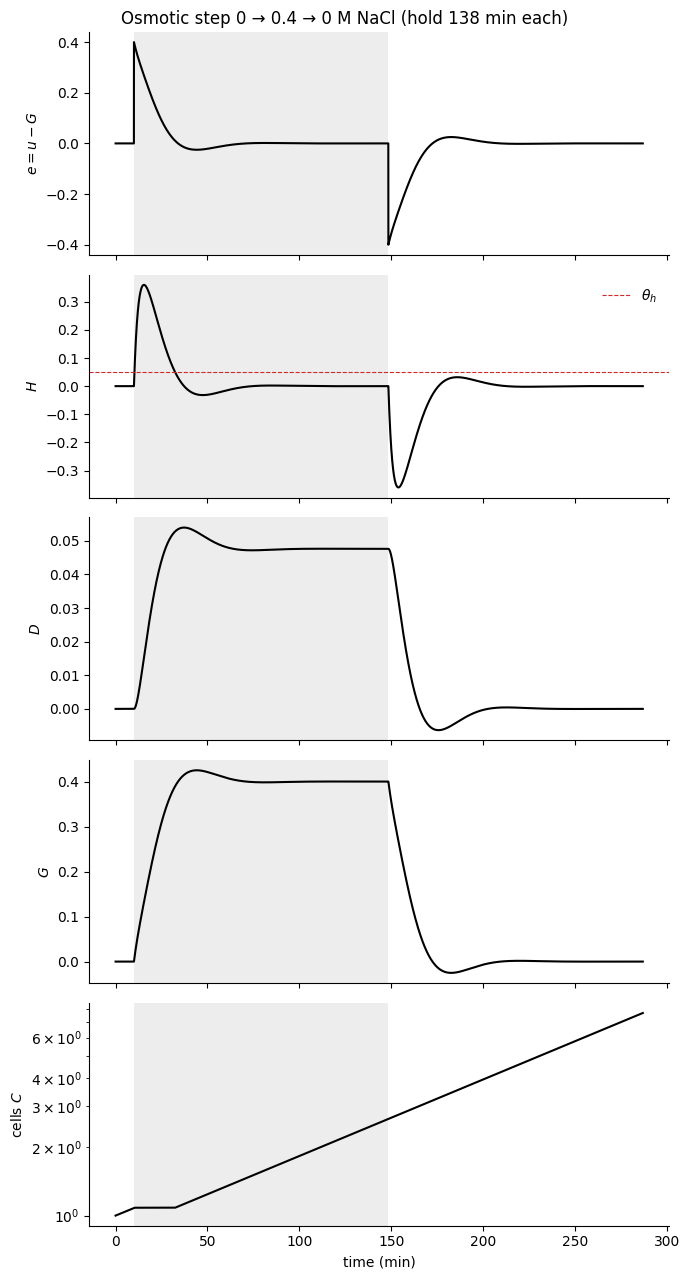

In [ ]:
# Step up 0 -> 0.4 M, hold until convergence, then back to 0 M and hold until convergence.
# Hold time = 10 time constants of the slowest mode of the linear (s1, s2, s3) system.
A = np.array([[-p['gamma_h'], 0, -p['k_h']],
              [p['alpha_d'], 0, 0],
              [0, 1, -(p['alpha_i'] + p['gamma_g'])]])
t_hold = 10.0 / np.abs(np.linalg.eigvals(A).real).min()

t_on = 10.0
t_off = t_on + t_hold
u_pulse = lambda t: u1 if t_on <= t < t_off else 0.0

res_pulse = simulate(u_pulse, (0.0, t_off + t_hold), n=8000, **p)

fig, axes = plt.subplots(len(panels), 1, figsize=(7, 13), sharex=True)
for ax, (key, label) in zip(axes, panels):
    ax.axvspan(t_on, t_off, color=SHADE_COLOR, lw=0, zorder=0)
    ax.plot(res_pulse['t'], res_pulse[key], color='k', lw=1.5)
    ax.set_ylabel(label)
axes[1].axhline(p_growth['theta_h'], color='tab:red', ls='--', lw=0.8, label=r'$\theta_h$')
axes[1].legend(frameon=False)
axes[-1].set_yscale('log')
axes[-1].set_xlabel('time (min)')
fig.suptitle(f'Osmotic step 0 → {u1} → 0 M NaCl (hold {t_hold:.0f} min each)')
fig.tight_layout()
plt.show()

Figure saved to ../plots/yeast_hog1_oscillation.pdf


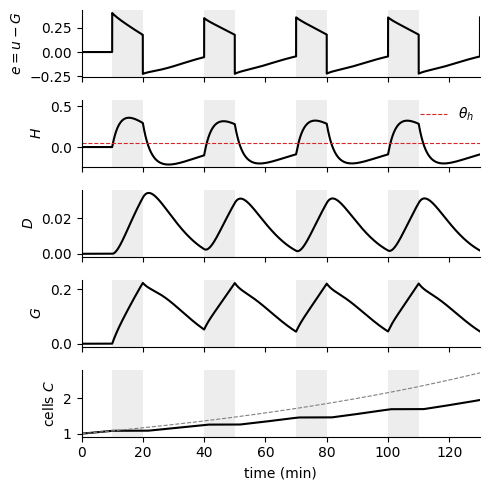

In [ ]:
# Oscillating input: square wave, u1 for T_on, then 0 for T_off, starting at t_start
T_on, T_off = 10.0, 20.0
n_cycles = 4
t_start = 10.0
T = T_on + T_off
u_osc = lambda t: u1 if t >= t_start and (t - t_start) % T < T_on else 0.0
t_span_osc = (0.0, t_start + n_cycles * T)

res_osc = simulate(u_osc, t_span_osc, n=8000, **p)

# input shown as shaded background (high osmolarity on)
fig, axes = plt.subplots(len(panels), 1, figsize=(5, 5), sharex=True)
for ax, (key, label) in zip(axes, panels):
    for k in range(n_cycles):
        ax.axvspan(t_start + k * T, t_start + k * T + T_on, color=SHADE_COLOR, lw=0, zorder=0)
    ax.plot(res_osc['t'], res_osc[key], color='k', lw=1.5)
    ax.set_ylabel(label)
axes[1].axhline(p_growth['theta_h'], color='tab:red', ls='--', lw=0.8, label=r'$\theta_h$')
ymin, ymax = axes[1].get_ylim()
axes[1].set_ylim(ymin, ymax + 0.3 * (ymax - ymin))   # headroom for the legend
axes[1].legend(frameon=False, loc='upper right', borderaxespad=0)
axes[-1].plot(res_osc['t'], np.exp(p_growth['c1'] * res_osc['t']), color='gray', ls='--', lw=0.8,
              )
# axes[-1].set_yscale('log')
axes[-1].yaxis.set_major_locator(LogLocator(base=2))
axes[-1].yaxis.set_minor_locator(NullLocator())
axes[-1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}'))
axes[-1].set_xlim(t_span_osc)
axes[-1].set_xlabel('time (min)')
fig.tight_layout()
save_fig(fig, f'yeast_hog1_oscillation.pdf')
plt.show()